# GROUP PROJECT

## Importing libraries

In [2]:
#
import numpy as np
import pandas as pd

# Data visualisation
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# sklearn related
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

#
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import L1, L2
#
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from keras.layers import Input, Dense, Dropout
from keras.optimizers import Adam, SGD, Adagrad, Adadelta, RMSprop
from keras.utils import to_categorical

# cnn related
from keras.layers import Conv2D, Flatten, MaxPooling2D, GlobalAveragePooling2D, BatchNormalization


# sort later :3
import tensorflow as tf
import math
from collections import Counter
from PIL import Image as PilImage

# manipulating files
import cv2
from tqdm import tqdm
import os
import ast

# For image showing
from IPython.display import Image, display
import matplotlib.pyplot as plt
import os

In [3]:
# os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress INFO and WARNING messages

# tf.config.optimizer.set_jit(True)

# Enable Mixed Precision policy at the start
# from tensorflow.keras.mixed_precision import set_global_policy
# set_global_policy('mixed_float16')

from ultralytics import YOLO
from transformers import CLIPProcessor, CLIPModel
import torch

c:\Users\User\miniforge3\envs\dl\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Import custom functions
from custom_function import * 
%load_ext autoreload
%autoreload 2

In [5]:
directory = 'rare_species/'

In [6]:
# Cheak if GPU is detected
print(f"Cuda is availible: {torch.cuda.is_available()}")
print("GPUs detected:", tf.config.list_physical_devices('GPU'))

Cuda is availible: False
GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [7]:
metadata = pd.read_csv(f'{directory}metadata.csv')

## Data exploration

### Metadata exploration

#### Basic exploration

In [8]:
metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11983 entries, 0 to 11982
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   rare_species_id  11983 non-null  object
 1   eol_content_id   11983 non-null  int64 
 2   eol_page_id      11983 non-null  int64 
 3   kingdom          11983 non-null  object
 4   phylum           11983 non-null  object
 5   family           11983 non-null  object
 6   file_path        11983 non-null  object
dtypes: int64(2), object(5)
memory usage: 655.4+ KB


In [9]:
metadata.head()

,rare_species_id,eol_content_id,eol_page_id,kingdom,phylum,family,file_path
0,75fd91cb-2881-41cd-88e6-de451e8b60e2,12853737,449393,animalia,mollusca,unionidae,mollusca_unionidae/12853737_449393_eol-full-si...
1,28c508bc-63ff-4e60-9c8f-1934367e1528,20969394,793083,animalia,chordata,geoemydidae,chordata_geoemydidae/20969394_793083_eol-full-...
2,00372441-588c-4af8-9665-29bee20822c0,28895411,319982,animalia,chordata,cryptobranchidae,chordata_cryptobranchidae/28895411_319982_eol-...
3,29cc6040-6af2-49ee-86ec-ab7d89793828,29658536,45510188,animalia,chordata,turdidae,chordata_turdidae/29658536_45510188_eol-full-s...
4,94004bff-3a33-4758-8125-bf72e6e57eab,21252576,7250886,animalia,chordata,indriidae,chordata_indriidae/21252576_7250886_eol-full-s...


In [10]:
metadata.describe(include='O')

,rare_species_id,kingdom,phylum,family,file_path
count,11983,11983,11983,11983,11983
unique,11983,1,5,202,11983
top,75fd91cb-2881-41cd-88e6-de451e8b60e2,animalia,chordata,cercopithecidae,mollusca_unionidae/12853737_449393_eol-full-si...
freq,1,11983,9952,300,1


In [11]:
plot_phylum_counts(metadata)

In [12]:
plot_family_counts(metadata)

In [13]:
# Count at each taxonomic level
phylum_to_family = metadata.groupby(['phylum', 'family']).size().reset_index(name='count')

# Prepare data for Sankey
labels = list(metadata['phylum'].unique()) + list(metadata['family'].unique())
label_dict = {label: idx for idx, label in enumerate(labels)}

source = []
target = []
value = []

for _, row in phylum_to_family.iterrows():
    source.append(label_dict[row['phylum']])
    target.append(label_dict[row['family']])
    value.append(row['count'])

# Create Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels,
        color='#6366f1'
    ),
    link=dict(
        source=source,
        target=target,
        value=value,
        color='rgba(99, 102, 241, 0.3)'
    )
)])

fig.update_layout(
    title='<b>Taxonomic Hierarchy: Phylum → Family</b>',
    font=dict(size=12),
    height=800,
    width=1200
)

fig.show()

print("\n📊 TAXONOMIC DIVERSITY:")
print(f"Phylums: {metadata['phylum'].nunique()}")
print(f"Families: {metadata['family'].nunique()}")
print(f"Average families per phylum: {metadata['family'].nunique() / metadata['phylum'].nunique():.1f}")


📊 TAXONOMIC DIVERSITY:
Phylums: 5
Families: 202
Average families per phylum: 40.4


#### Retracting more information from the images

In [14]:
# # Extract more information about the images and save to the metadata df (6min)
# metadata['image_size'], metadata['color_channel'], metadata['format'], metadata['aspect_ratio'], \
# metadata['min_val'], metadata['max_val'] = explore_image_files(directory + metadata['file_path'], explore_values=True)

# Don't explore values to save time (1min)
metadata['image_size'], metadata['color_channel'], metadata['format'], metadata['aspect_ratio'] = explore_image_files(directory + metadata['file_path'])

c:\Users\User\miniforge3\envs\dl\lib\site-packages\PIL\Image.py:3432: DecompressionBombWarning:

Image size (115600000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.



In [15]:
# Compute width, height and pixel count
metadata['width'], metadata['height'] = zip(*metadata['image_size'])
metadata["pixel_count"] = metadata["width"] * metadata["height"]

In [16]:
metadata.describe()

,eol_content_id,eol_page_id,aspect_ratio,width,height,pixel_count
count,1.198300e+04,1.198300e+04,11983.000000,11983.000000,11983.000000,1.198300e+04
mean,2.297681e+07,2.112247e+07,1.332127,1924.600935,1512.260285,3.948089e+06
std,6.999289e+06,2.241319e+07,0.396398,1267.575315,951.330175,5.535964e+06
min,4.750000e+02,1.180080e+05,0.199919,170.000000,125.000000,2.489700e+04
25%,2.058937e+07,7.954560e+05,1.247341,1000.000000,768.000000,7.530000e+05
50%,2.251368e+07,2.865857e+06,1.333333,1784.000000,1365.000000,2.764800e+06
75%,2.932887e+07,4.551773e+07,1.500366,2048.000000,2013.500000,3.236208e+06
max,3.061946e+07,5.269200e+07,7.534247,17000.000000,8688.000000,1.156000e+08


huge file at "\rare_species\mollusca_cardiidae\30003931_46473744_eol-full-size-copy.jpg"

In [17]:
metadata.head()

,rare_species_id,eol_content_id,eol_page_id,kingdom,phylum,family,file_path,image_size,color_channel,format,aspect_ratio,width,height,pixel_count
0,75fd91cb-2881-41cd-88e6-de451e8b60e2,12853737,449393,animalia,mollusca,unionidae,mollusca_unionidae/12853737_449393_eol-full-si...,"(400, 400)",RGB,JPEG,1.000000,400,400,160000
1,28c508bc-63ff-4e60-9c8f-1934367e1528,20969394,793083,animalia,chordata,geoemydidae,chordata_geoemydidae/20969394_793083_eol-full-...,"(1596, 1066)",RGB,JPEG,1.497186,1596,1066,1701336
2,00372441-588c-4af8-9665-29bee20822c0,28895411,319982,animalia,chordata,cryptobranchidae,chordata_cryptobranchidae/28895411_319982_eol-...,"(2480, 1396)",RGB,JPEG,1.776504,2480,1396,3462080
3,29cc6040-6af2-49ee-86ec-ab7d89793828,29658536,45510188,animalia,chordata,turdidae,chordata_turdidae/29658536_45510188_eol-full-s...,"(1554, 2019)",RGB,JPEG,0.769688,1554,2019,3137526
4,94004bff-3a33-4758-8125-bf72e6e57eab,21252576,7250886,animalia,chordata,indriidae,chordata_indriidae/21252576_7250886_eol-full-s...,"(1365, 2048)",RGB,JPEG,0.666504,1365,2048,2795520


c:\Users\User\miniforge3\envs\dl\lib\site-packages\PIL\Image.py:3432: DecompressionBombWarning:

Image size (115600000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.



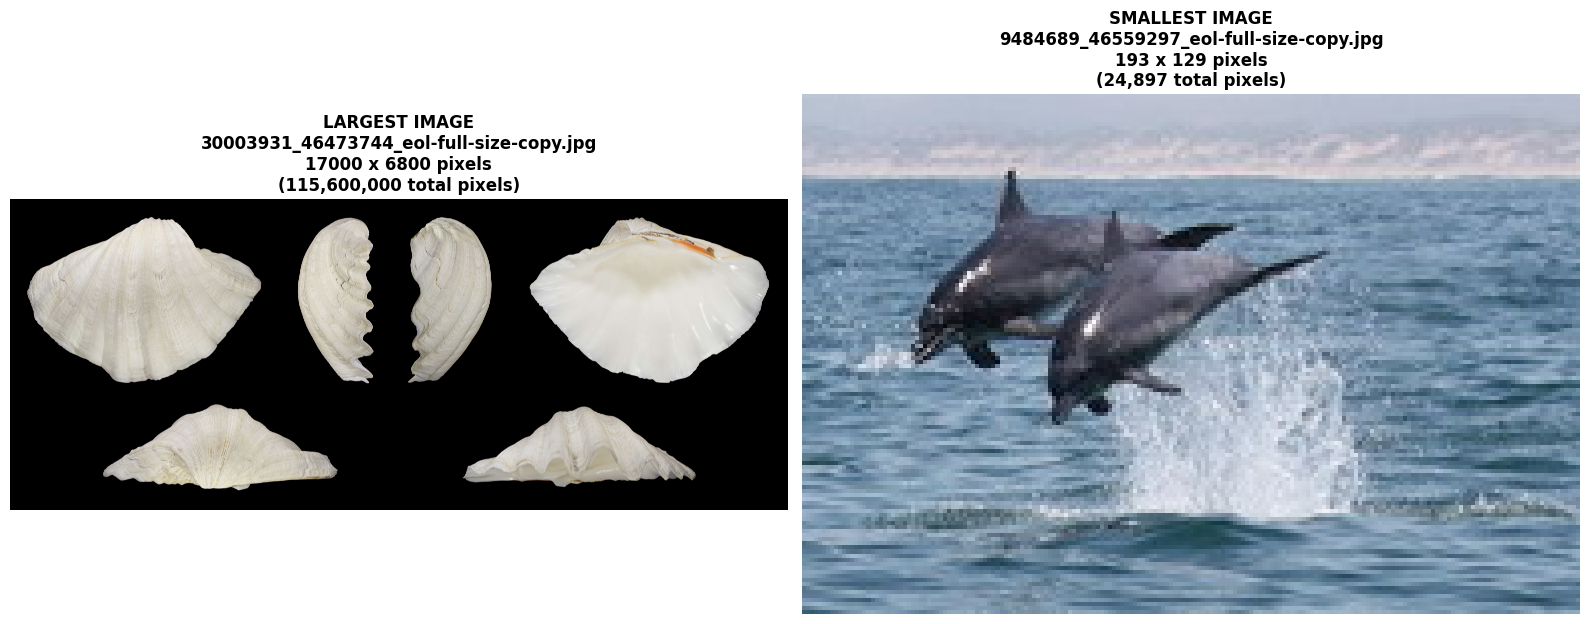

Largest image path:  rare_species/mollusca_cardiidae/30003931_46473744_eol-full-size-copy.jpg

Smallest image path: rare_species/chordata_delphinidae/9484689_46559297_eol-full-size-copy.jpg


In [18]:
smallest_largest_image(metadata, directory)

In [19]:
# Based on previous discoveries set up potencial boudaries for image scaling
common_ratio = 4/3
width_max = 500       

In [20]:
plot_image_size_scatter(metadata, common_ratio, width_max)

In [21]:
# Calculate the final image size
image_size = (width_max, round(width_max/common_ratio))
print(f"Best image size to scale to is {image_size}")

Best image size to scale to is (500, 375)


In [22]:
plot_color_chanels_counts(metadata)

### Images exploration

#### All images

In [23]:
# plot_images_from_directory(directory, img_per_class=5)

From plotting sample of the images we can see that have some unusial examples like:

- X-ray imagaes
- Images of signs
- Paintings
- Text extracts with no images
- Images unrelated to the class
- Maps
- Varying zoom / color / rotations

#### Grayscale and CMYK
Lets take a look at what are the different color formats

In [24]:
datagen = ImageDataGenerator(rescale=1./255)

# Get only greyscale images
temp_generator = datagen.flow_from_dataframe(
    dataframe=metadata[metadata.color_channel == 'L'],
    directory=directory,
    x_col='file_path',
    y_col='family',
    target_size=image_size,
    batch_size=32,
    class_mode='categorical',
    shuffle=False   # Not shuffling
)

Found 183 validated image filenames belonging to 62 classes.


In [25]:
# plot_images_from_generator(temp_generator)

We can see that most of Grayscale images are sketches, drawings, x-rays or just old phorots. Some images retain at least the shape of the actual animal, but most of them are really bad.

In [26]:
# Do the same for CMYK
temp_generator = datagen.flow_from_dataframe(
    dataframe=metadata[metadata.color_channel == 'CMYK'],
    directory=directory,
    x_col='file_path',
    y_col='family',
    target_size=image_size,
    batch_size=32,
    class_mode='categorical',
    shuffle=False   # Not shuffling
)

Found 178 validated image filenames belonging to 8 classes.


In [27]:
# plot_images_from_generator(temp_generator)

Most of the images apper to be x-rays of sculls of different types of monkeys and apes, which don't really help identify the animals by the picture, and will more likely only confuse the model. \
(and there are 2 different images for some reason: 1 with 2 parrots and another with a turtle)

In [28]:
# See what is the class distribution amoung the greyscale images
unique, counts = np.unique(temp_generator.classes, return_counts=True)
counts_per_class = dict(zip(unique, counts))

idx_to_class = {v: k for k, v in temp_generator.class_indices.items()}

for idx, count in counts_per_class.items():
    print(f"{idx_to_class[idx]}: {count} images")

aotidae: 36 images
atelidae: 27 images
callitrichidae: 30 images
cercopithecidae: 42 images
emydidae: 1 images
hominidae: 4 images
hylobatidae: 37 images
psittacidae: 1 images


In [29]:
# Changing good CMYK images to RGB in the metadata to keep them in the dataset

metadata.loc[metadata['family'].isin(['chordata_emydidae', 'chordata_psittacidae']) & 
             (metadata['color_channel'] == 'CMYK'), 'color_channel'] = 'RGB'

## Preprocessing

### Remove CMYK and Grayscale

In [30]:
# Remove CMYK and Grayscale images from metadata
print(f"Original metadata size: {len(metadata)}")
metadata = metadata[~metadata['color_channel'].isin(['CMYK', 'L'])].reset_index(drop=True)
print(f"After removing CMYK/grayscale: {len(metadata)}")

Original metadata size: 11983
After removing CMYK/grayscale: 11622


### Outlier detection

#### YOLO

In [36]:
# Set up the parameters for the model
MODEL_ID = 'yolov8s.pt'
CONFIDENCE_THRESHOLD = 0.85
PERSON_CLASS_ID = 0

In [37]:
def find_images_with_people(metadata, directory, model_id, conf_threshold, person_class_id):
    """Find images containing people using YOLO."""

    print(f"Loading {model_id}...")
    model = YOLO(model_id)
    
    has_person = []
    person_confidence = []
    
    print(f"Scanning for people with confidence > {conf_threshold}.")
    
    for idx, row in tqdm(metadata.iterrows(), total=len(metadata), desc="YOLO person detection"):
        filepath = os.path.join(directory, row['file_path'])
        
        try:
            results = model.predict(
                filepath,
                verbose=False,
                conf=conf_threshold,
                iou=0.5,
                classes=[person_class_id]
            )
            
            boxes = results[0].boxes if results and results[0].boxes is not None else None
            
            if boxes and len(boxes) > 0:
                has_person.append(True)
                person_confidence.append(float(boxes.conf.max()))
            else:
                has_person.append(False)
                person_confidence.append(0.0)
                
        except Exception as e:
            has_person.append(False)
            person_confidence.append(0.0)
    
    return has_person, person_confidence

In [38]:
# Run YOLO person detection
metadata['has_person'], metadata['person_confidence'] = find_images_with_people(metadata, directory, MODEL_ID, CONFIDENCE_THRESHOLD, PERSON_CLASS_ID)

print(f"\nYOLO Results:")
print(f"  Images with people: {metadata['has_person'].sum()}")
print(f"  Images without people: {(~metadata['has_person']).sum()}")

Loading yolov8s.pt...
Scanning for people with confidence > 0.85.


YOLO person detection: 100%|██████████| 11622/11622 [11:52<00:00, 16.31it/s]


YOLO Results:
  Images with people: 184
  Images without people: 11438


#### Clip

In [31]:
# Check for GPU/MPS availability
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Using device: {device}")

Using device: cpu


In [32]:
# Load CLIP model
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Define semantic categories
text_prompts = [
    # Good categories (KEEP) - indices 0-2
    "a photograph of an animal",
    "a wildlife photograph",
    "a photo of an animal in nature",
    
    # Bad categories (REMOVE) - indices 3+
    "an x-ray image",
    "a medical scan",
    "a drawing or sketch",
    "a map or diagram",
    "text document or book page",
    "a logo or icon",
    "a cooked meal",
    "prepared food",
    "a human",
    "a photo of a person",
    "a portrait of a human face",
    "people in a photograph",
    "a group of people",
    "a scientist or researcher",
]

# Precompute text embeddings
text_inputs = clip_processor(text=text_prompts, return_tensors="pt", padding=True).to(device)
with torch.no_grad():
    text_features = clip_model.get_text_features(**text_inputs)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [33]:
def compute_clip_scores_batch(metadata, directory, batch_size=32):
    """Process all images and compute CLIP semantic scores."""
    all_results = []
    file_paths = metadata['file_path'].tolist()
    
    for i in tqdm(range(0, len(file_paths), batch_size), desc="Computing CLIP scores"):
        batch_paths = file_paths[i:i+batch_size]
        batch_images = []
        batch_indices = []
        
        for j, path in enumerate(batch_paths):
            try:
                full_path = directory + path
                img = PilImage.open(full_path).convert("RGB")
                batch_images.append(img)
                batch_indices.append(i + j)
            except Exception as e:
                all_results.append({
                    'clip_photo_score': None,
                    'clip_noise_score': None,
                    'clip_semantic_quality': None,
                    'clip_best_match': None
                })
        
        if not batch_images:
            continue
        
        image_inputs = clip_processor(images=batch_images, return_tensors="pt", padding=True).to(device)
        
        with torch.no_grad():
            image_features = clip_model.get_image_features(**image_inputs)
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)
            similarities = (image_features @ text_features.T).cpu().numpy()
        
        for sims in similarities:
            photo_score = sims[:3].max()
            noise_score = sims[3:].max()
            all_results.append({
                'clip_photo_score': float(photo_score),
                'clip_noise_score': float(noise_score),
                'clip_semantic_quality': float(photo_score - noise_score),
                'clip_best_match': text_prompts[sims.argmax()]
            })
    
    return pd.DataFrame(all_results)

In [34]:
# Run CLIP scoring on your metadata
print("Computing CLIP semantic scores...")
clip_results = compute_clip_scores_batch(metadata, directory, batch_size=32)

# Add CLIP columns to metadata
metadata['clip_photo_score'] = clip_results['clip_photo_score']
metadata['clip_noise_score'] = clip_results['clip_noise_score']
metadata['clip_semantic_quality'] = clip_results['clip_semantic_quality']
metadata['clip_best_match'] = clip_results['clip_best_match']

print(f"\nProcessed {len(metadata)} images")

Computing CLIP semantic scores...


Computing CLIP scores:  85%|████████▍ | 309/364 [17:17<03:04,  3.36s/it]c:\Users\User\miniforge3\envs\dl\lib\site-packages\PIL\Image.py:3432: DecompressionBombWarning:

Image size (115600000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.

Computing CLIP scores: 100%|██████████| 364/364 [20:13<00:00,  3.33s/it]


Processed 11622 images


#### Imagenet detection

In [43]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image

# Load the model
imagenet_model = InceptionV3(weights='imagenet')

In [44]:
# ImageNet animal detection helper function
def check_animal_presence(img_path, model, threshold=0.02):
    """Check if an image contains an animal using ImageNet predictions."""

    # ImageNet animal class indices (classes 0-397 are animals)
    # Full list: https://gist.github.com/yrevar/942d3a0ac09ec9e5eb3a
    ANIMAL_CLASS_RANGE = (0, 398)  # Classes 0-397 are animals in ImageNet
    
    try:
        # Load and preprocess image
        img = image.load_img(img_path, target_size=(299, 299))
        x = image.img_to_array(img)
        x = np.expand_dims(x, axis=0)
        x = preprocess_input(x)
        
        # Get predictions
        preds = model.predict(x, verbose=0)
        decoded = decode_predictions(preds, top=10)[0]
        
        # Get top prediction
        top_class = decoded[0][1]
        top_prob = float(decoded[0][2])
        
        # Check if any animal class has high probability
        animal_prob = 0.0
        is_animal = False
        
        for pred in decoded:
            class_idx = pred[0]
            class_name = pred[1]
            prob = float(pred[2])
            
            # ImageNet classes 0-397 are animals
            # We can also check by keywords
            animal_keywords = [
                'dog', 'cat', 'bird', 'fish', 'snake', 'turtle', 'frog',
                'insect', 'butterfly', 'spider', 'crab', 'lobster', 'snail',
                'worm', 'jellyfish', 'coral', 'lion', 'tiger', 'bear',
                'elephant', 'monkey', 'ape', 'whale', 'dolphin', 'seal',
                'penguin', 'eagle', 'owl', 'parrot', 'lizard', 'crocodile',
                'salamander', 'scorpion', 'beetle', 'bee', 'ant', 'fly',
                'cockroach', 'mantis', 'dragonfly', 'moth', 'slug'
            ]
            
            # Check if it's likely an animal
            if any(keyword in class_name.lower() for keyword in animal_keywords):
                if prob > animal_prob:
                    animal_prob = prob
                    is_animal = True
        
        # If no keyword match, use class index range
        if not is_animal and top_prob > threshold:
            # Approximate check: most animals are in lower class indices
            # This is a heuristic - adjust as needed
            pass
        
        is_animal = animal_prob >= threshold
        
        return is_animal, animal_prob, top_class, top_prob
        
    except Exception as e:
        print(f"Error processing {img_path}: {e}")
        return False, 0.0, "error", 0.0

In [45]:
# Run ImageNet animal detection
is_animal_list = []
animal_prob_list = []
top_class_list = []
top_prob_list = []

for idx, row in tqdm(metadata.iterrows(), total=len(metadata), desc="ImageNet animal detection"):
    img_path = os.path.join(directory, row['file_path'])
    is_animal, animal_prob, top_class, top_prob = check_animal_presence(
        img_path, imagenet_model, threshold=0.02
    )
    is_animal_list.append(is_animal)
    animal_prob_list.append(animal_prob)
    top_class_list.append(top_class)
    top_prob_list.append(top_prob)

metadata['has_animal'] = is_animal_list
metadata['animal_confidence'] = animal_prob_list
metadata['predicted_class'] = top_class_list
metadata['prediction_confidence'] = top_prob_list

print(f"\nImageNet Results:")
print(f"  Images with animals: {metadata['has_animal'].sum()}")
print(f"  Images without animals: {(~metadata['has_animal']).sum()}")

ImageNet animal detection:  85%|████████▌ | 9898/11622 [14:01<02:42, 10.60it/s]c:\Users\User\miniforge3\envs\dl\lib\site-packages\PIL\Image.py:3432: DecompressionBombWarning:

Image size (115600000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.

ImageNet animal detection: 100%|██████████| 11622/11622 [16:42<00:00, 11.60it/s]


ImageNet Results:
  Images with animals: 6947
  Images without animals: 4675


#### Visualization / Comparisons

In [46]:
def show_yolo_detections(metadata, directory, N, n_cols=10):
    """Display images where YOLO detected people."""
    person_images = metadata[metadata['has_person'] == True].copy()
    person_images = person_images.sort_values('person_confidence', ascending=False)
    
    if len(person_images) == 0:
        print("No images with people detected by YOLO!")
        return
    
    # Take a sample for plotting
    person_images = person_images.sample(min(N, len(person_images)))

    print(f"Showing {len(person_images)} images with people detected by YOLO\n")
    
    n_rows = math.ceil(len(person_images) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2*n_cols, 2.5*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes
    
    for idx, (_, row) in enumerate(person_images.iterrows()):
        try:
            img = PilImage.open(directory + row['file_path'])
            axes[idx].imshow(img)
            axes[idx].set_title(f"conf: {row['person_confidence']:.2f}", fontsize=6)
        except:
            pass
        axes[idx].axis('off')
    
    for idx in range(len(person_images), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f"YOLO Person Detections ({len(person_images)} images)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [47]:
def show_all_clip_outliers(metadata, directory, N, n_cols=10):
    """Display ALL CLIP outliers."""
    bad_images = metadata[metadata['clip_semantic_quality'] < 0].copy()
    bad_images = bad_images.sort_values('clip_semantic_quality', ascending=True)
    
    if len(bad_images) == 0:
        print("No CLIP outliers found!")
        return
    
    print(f"CLIP Category breakdown (total {len(bad_images)}):")
    print(bad_images['clip_best_match'].value_counts())
    print("\n" + "="*60 + "\n")

    # Take a sample for plotting
    bad_images = bad_images.sample(min(N, len(bad_images)))
    
    print(f"Showing {len(bad_images)} CLIP outliers\n")
    
    n_rows = math.ceil(len(bad_images) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2*n_cols, 2.5*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes
    
    for idx, (_, row) in enumerate(bad_images.iterrows()):
        try:
            img = PilImage.open(directory + row['file_path'])
            axes[idx].imshow(img)
            axes[idx].set_title(
                f"{row['clip_best_match'].replace('a ', '').replace('an ', '')[:15]}\n"
                f"{row['clip_semantic_quality']:.2f}",
                fontsize=6
            )
        except:
            pass
        axes[idx].axis('off')
    
    for idx in range(len(bad_images), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f"CLIP Outliers ({len(bad_images)} images)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [48]:
def show_non_animal_images(metadata, directory, n_rows=5, n_cols=10):
    """Display images where ImageNet didn't detect animals."""
    non_animals = metadata[metadata['has_animal'] == False].copy()
    non_animals = non_animals.sort_values('animal_confidence', ascending=True)
    
    if len(non_animals) == 0:
        print("All images contain animals!")
        return
    
    n_show = min(n_cols * n_rows, len(non_animals))
    print(f"Showing {n_show} of {len(non_animals)} non-animal images detected by InceptionV3\n")
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2*n_cols, 2.5*n_rows))
    axes = axes.flatten()
    
    for idx, (_, row) in enumerate(non_animals.head(n_show).iterrows()):
        try:
            img = PilImage.open(directory + row['file_path'])
            axes[idx].imshow(img)
            axes[idx].set_title(
                f"{row['predicted_class'][:12]}\n{row['animal_confidence']:.3f}",
                fontsize=6
            )
        except:
            pass
        axes[idx].axis('off')
    
    for idx in range(n_show, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f"ImageNet Non-Animal Images ({len(non_animals)} total)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [49]:
# show_yolo_detections(metadata, directory, 100)

In [50]:
# show_non_animal_images(metadata, directory, n_cols=10)

In [51]:
# show_all_clip_outliers(metadata, directory, 100)

### Outlier removal

In [35]:
# Remove the outliers based on CLIP results
outliers = metadata[metadata['clip_semantic_quality'] < 0].copy()
metadata = metadata[metadata['clip_semantic_quality'] >= 0].reset_index(drop=True)

In [36]:
# See what class has the least images (save the family name for later)
low_images_class = metadata['family'].value_counts().idxmin()
print(f"Total images after removing inconsistencies: {len(metadata)} out of {len(metadata) + len(outliers)} ({len(outliers)} removed)")
print(f"The lowest amount of images per class is '{low_images_class}' with {metadata['family'].value_counts().iloc[-1]} images")

Total images after removing inconsistencies: 10982 out of 11622 (640 removed)
The lowest amount of images per class is 'brachypteraciidae' with 16 images


### Generate embeddings

In [ ]:
# Import pretrained model   
from tensorflow.keras.applications import EfficientNetB4 

# Import the preprocess_input that corresponds to the model
# from tensorflow.keras.applications.efficientnet import preprocess_input

In [141]:
# Load pre-trained EfficientNet without the top classification layer
embedding_model = EfficientNetB4(weights='imagenet', include_top=False, pooling='avg')
print(f"Embedding dimension: {embedding_model.output_shape[-1]}")

Embedding dimension: 1792


In [142]:
# Create generator with preprocessing form the model
datagen = ImageDataGenerator() #preprocessing_function=preprocess_input)

# Create generator 
preprocessing_generator = datagen.flow_from_dataframe(
    dataframe=metadata,
    directory=directory,
    x_col='file_path',
    y_col='family',  
    target_size=image_size,
    batch_size=32,  
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False       # Not to mess up the order with df
)


# Generate embeddings
embeddings_list = []

# Calculate number of batches
num_batches = len(preprocessing_generator)

for i in tqdm(range(num_batches), desc="Embedding images"):  # Add a fancy progress bar
    batch_images, _ = next(preprocessing_generator)  # Get images (ignore labels)
    
    # Generate embeddings
    batch_embeddings = embedding_model.predict(batch_images, verbose=0) 
    embeddings_list.extend(batch_embeddings)

Found 10982 validated image filenames belonging to 202 classes.


Embedding images: 100%|██████████| 344/344 [04:02<00:00,  1.42it/s]


In [143]:
# Add embedings to metadata
metadata['embedding'] = embeddings_list

### Remove inconsistencies

In [144]:
# Stratified split the metadata not to leak the test embeddings
train_df, test_df = train_test_split(
  metadata,   # Use only good images
  test_size=0.15,
  stratify=metadata['family'],
  shuffle=True,
  random_state=42
)

In [145]:
# Calculate distance to centroids (centroids are based only on train embeddings)
train_df['distance_to_centroid'], test_df['distance_to_centroid'] = distance_to_centroid(train_df, test_df)

In [43]:
# plot_furthest_images_batched(directory, train_df, 500)

In [146]:
# Identify outliers based on distance to centroid of the train_df
threshold = train_df['distance_to_centroid'].quantile(0.95) 

# Copy outliers in case we want them later for analysis
outliers_train = train_df[train_df['distance_to_centroid'] > threshold].copy()
outliers_test = test_df[test_df['distance_to_centroid'] > threshold].copy()     

train_df = train_df[train_df['distance_to_centroid'] <= threshold].copy()
test_df = test_df[test_df['distance_to_centroid'] <= threshold].copy()

print(f"Removed {len(outliers_train)} outliers from train data")
print(f"Removed {len(outliers_test)} outliers from test data")

Removed 467 outliers from train data
Removed 111 outliers from test data


In [147]:
# See what class has the least images (save the family name for later)
low_images_class = train_df['family'].value_counts().idxmin()
print(f"Total images after removing inconsistencies: {len(train_df) + len(test_df)} (out of {len(metadata)})")
print(f"Images left for training: {len(train_df)}. Images left for testing: {len(test_df)}.")
print(f"The lowest amount of images per class is '{low_images_class}' with {train_df['family'].value_counts().iloc[-1]} images for training and {test_df['family'].value_counts().iloc[-1]} images for testing")

Total images after removing inconsistencies: 10404 (out of 10982)
Images left for training: 8867. Images left for testing: 1537.
The lowest amount of images per class is 'brachypteraciidae' with 13 images for training and 2 images for testing


In [148]:
# Recalculate centroids
train_df.drop('distance_to_centroid', axis=1, inplace=True)
test_df.drop('distance_to_centroid', axis=1, inplace=True)
train_df['distance_to_centroid'], test_df['distance_to_centroid'] = distance_to_centroid(train_df, test_df)

In [47]:
# plot_furthest_images_batched(directory, train_df, 300)

In [149]:
# Identify outliers based on distance to centroid of the train_df
threshold = train_df['distance_to_centroid'].quantile(0.975) 

# Copy outliers in case we want them later for analysis
outliers_train = pd.concat([outliers_train, train_df[train_df['distance_to_centroid'] > threshold]], ignore_index=True)
outliers_test = pd.concat([outliers_test, test_df[test_df['distance_to_centroid'] > threshold]], ignore_index=True)   

train_df = train_df[train_df['distance_to_centroid'] <= threshold].copy()
test_df = test_df[test_df['distance_to_centroid'] <= threshold].copy()

print(f"Removed Total of {len(outliers_train)} outliers from train data")
print(f"Removed Total of {len(outliers_test)} outliers from test data")

Removed Total of 689 outliers from train data
Removed Total of 153 outliers from test data


In [150]:
# See what class has the least images (save the family name for later)
low_images_class = train_df['family'].value_counts().idxmin()
print(f"Total images after removing inconsistencies: {len(train_df) + len(test_df)} (out of {len(metadata)})")
print(f"Images left for training: {len(train_df)}. Images left for testing: {len(test_df)}.")
print(f"The lowest amount of images per class is '{low_images_class}' with {train_df['family'].value_counts().iloc[-1]} images for training and {test_df['family'].value_counts().iloc[-1]} images for testing")

Total images after removing inconsistencies: 10140 (out of 10982)
Images left for training: 8645. Images left for testing: 1495.
The lowest amount of images per class is 'brachypteraciidae' with 13 images for training and 1 images for testing


In [50]:
# plot_furthest_images_batched(directory, train_df, 30)

In [97]:
# plot_furthest_images_batched(directory, train_df[train_df.family == low_images_class], 20)

### Split the data

In [151]:
# Set apart of train for validation
train_df, val_df = train_test_split(
  train_df,
  test_size=0.1,
  stratify=train_df['family'],
  shuffle=True,
  random_state=42
)

# Print the final proportions of the split
total_data_len = len(train_df) + len(val_df) + len(test_df)     # Amout of data after cleaning
print(f"Training  : {len(train_df)} ({round(len(train_df)/total_data_len*100)}%) \
        \nValidation: {len(val_df)} ({round(len(val_df)/total_data_len*100)}%)  \
        \nTesting   : {len(test_df)} ({round(len(test_df)/total_data_len*100)}%) \
        \nTotal     : {total_data_len}")

Training  : 7780 (77%)         
Validation: 865 (9%)          
Testing   : 1495 (15%)         
Total     : 10140


In [ ]:
# Set up train generator with data augmentatin AND preprocessing
train_datagen = ImageDataGenerator(
    horizontal_flip=True,       # Only horizontal flip
    rotation_range=15,          # Small rotation only
    zoom_range=0.1,             # Small zoom only
    fill_mode='nearest',        # Fill mode
    # width_shift_range=0.10,
    # height_shift_range=0.10,
    # preprocessing_function=preprocess_input
)

# Validation/Test generator (no augmentation) only preprocessing
test_datagen = ImageDataGenerator()

In [153]:
# Create train from train_datagen
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=directory,
    x_col='file_path',
    y_col='family',
    target_size=image_size,     # Transform to image_size
    batch_size=32,
    class_mode='sparse',        # Use sparse for integer labels
    color_mode='rgb',           # Convert all the images to RGB
    shuffle=True, 
    seed=42
)

# And validation and test from test_datagen
val_generator = test_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=directory,
    x_col='file_path',
    y_col='family',
    target_size=image_size,
    batch_size=32,
    class_mode='sparse',  
    color_mode='rgb',
    shuffle=False, 
    seed=42
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=directory,
    x_col='file_path',
    y_col='family',
    target_size=image_size,
    batch_size=32,
    class_mode='sparse',  
    color_mode='rgb',
    shuffle=False,              # !! Not shuffling for reproducibility
    seed=42
    )

Found 7780 validated image filenames belonging to 202 classes.
Found 865 validated image filenames belonging to 202 classes.
Found 1495 validated image filenames belonging to 202 classes.


In [154]:
#  Critical debug check
images, labels = next(train_generator)

print(f"VALIDATION CHECKS:")
print(f"Image batch shape: {images.shape}")
print(f"Image value range: [{images.min():.3f}, {images.max():.3f}]")
print(f"Labels shape: {labels.shape}")
print(f"Labels range: [{labels.min()}, {labels.max()}]")
print(f"Unique labels in batch: {len(np.unique(labels))}")
print(f"Any all-zero images: {(images.sum(axis=(1,2,3)) == 0).any()}")

VALIDATION CHECKS:
Image batch shape: (32, 500, 375, 3)
Image value range: [0.000, 255.000]
Labels shape: (32,)
Labels range: [10.0, 194.0]
Unique labels in batch: 28
Any all-zero images: False


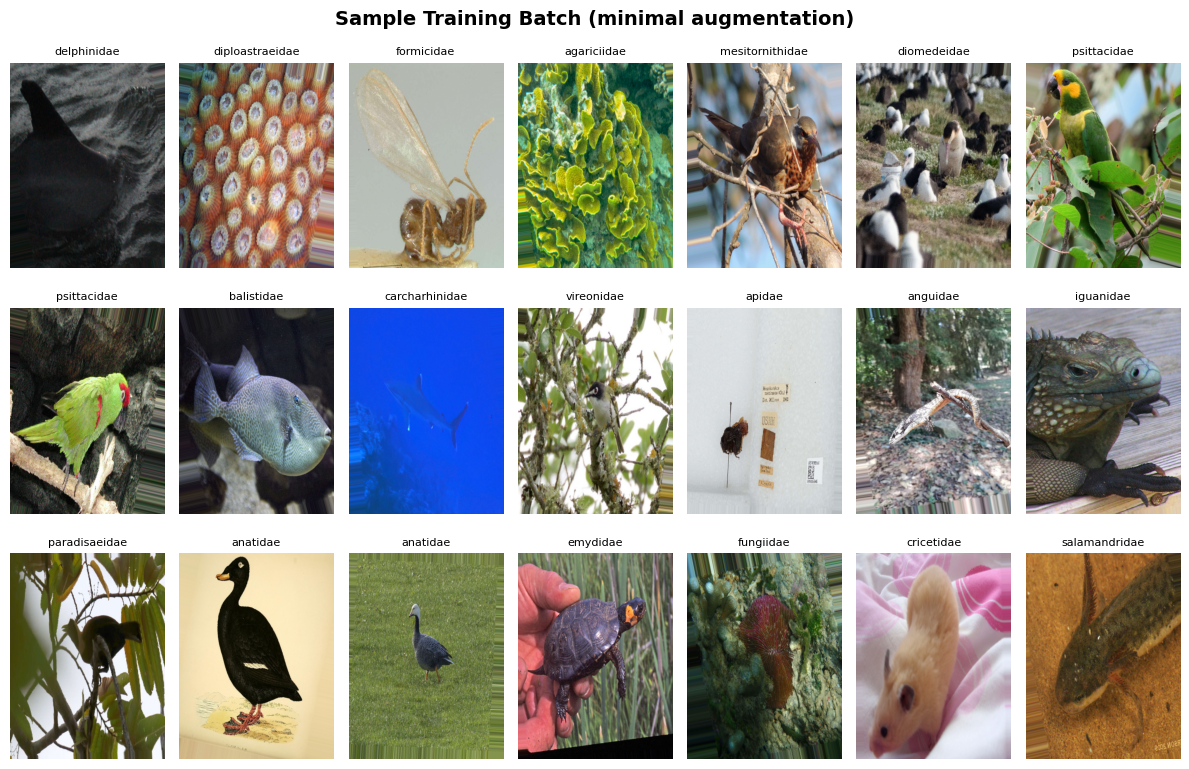

In [155]:
# Get a fresh batch
images, labels = next(train_generator)

# Get class names
class_names = list(train_generator.class_indices.keys())

# Plot the images
plt.figure(figsize=(12, 8))

for i in range(min(21, len(images))):
    ax = plt.subplot(3, 7, i + 1)
    # Denormalize for visualization
    img_display = images[i].copy()
    img_display = (img_display - img_display.min()) / (img_display.max() - img_display.min())
    plt.imshow(img_display)
    plt.title(class_names[int(labels[i])], fontsize=8)
    plt.axis("off")

plt.suptitle("Sample Training Batch (minimal augmentation)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Modeling


In [159]:
N_CLASSES = len(train_generator.class_indices)
print(f"Number of classes: {N_CLASSES}")

Number of classes: 202


### Transfer learning with keras base model

#### EfficientNetB4

In [ ]:
# Import pretrained model   
from tensorflow.keras.applications import EfficientNetB4 

In [271]:
# Get the base model set up
base_model_B4 = EfficientNetB4(
    weights='imagenet',
    include_top=False,
    input_shape=(*image_size, 3) 
)

# Freeze base model initially
base_model_B4.trainable = False

In [272]:
# Calculate the class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))

In [273]:
# # Build the classifier
with tf.device('/GPU:0'):   # Move the model to gpu
    modelB4 = Sequential([
        base_model_B4,
        GlobalAveragePooling2D(),
        BatchNormalization(),

        Dense(800, kernel_regularizer=L2(0.01)),
        BatchNormalization(),
        Dropout(0.1),

        Dense(N_CLASSES, kernel_regularizer=L2(0.01), activation='softmax')
    ])

In [274]:
# See the parameter counts
print("Total params:", modelB4.count_params())
print("Non-trainable params:", sum([tf.size(w).numpy() for w in modelB4.non_trainable_weights]))
print("Trainable params:", sum([tf.size(w).numpy() for w in modelB4.trainable_weights]))

Total params: 19280393
Non-trainable params: 17679007
Trainable params: 1601386


In [ ]:
# Compile the model
modelB4.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',     
    metrics=['accuracy'] 
)

# Set up callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

# Fit the model
historyB4 = modelB4.fit(
    train_generator,
    epochs=15,
    batch_size=400,
    class_weight=class_weight_dict,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
258/258 [==============================] - 208s 786ms/step - loss: 9.7998 - accuracy: 0.5104 - val_loss: 5.3409 - val_accuracy: 0.6408 - lr: 0.0010
Epoch 2/15
258/258 [==============================] - 202s 781ms/step - loss: 3.6459 - accuracy: 0.6415 - val_loss: 3.0953 - val_accuracy: 0.6583 - lr: 0.0010
Epoch 3/15
258/258 [==============================] - 202s 780ms/step - loss: 2.7892 - accuracy: 0.6481 - val_loss: 2.7220 - val_accuracy: 0.6736 - lr: 0.0010
Epoch 4/15
258/258 [==============================] - 202s 782ms/step - loss: 2.6995 - accuracy: 0.6505 - val_loss: 2.7988 - val_accuracy: 0.6277 - lr: 0.0010
Epoch 5/15
258/258 [==============================] - ETA: 0s - loss: 2.7008 - accuracy: 0.6286
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
258/258 [==============================] - 202s 782ms/step - loss: 2.7008 - accuracy: 0.6286 - val_loss: 2.7878 - val_accuracy: 0.6310 - lr: 0.0010
Epoch 6/15
258/258 [========================

In [276]:
plot_model_results(historyB4, 'loss')

In [277]:
plot_model_results(historyB4, 'accuracy')

Because EfficientNetB4 is trained on millions of pictures it does not make sense to fine-tune it when we only have 15 images per some classes. But even if we wanted to try it is too heavy of model, and we would not able to fit in on the GPU even with a very small batch size.

#### Hyperband parameter search

In [58]:
from tensorflow import keras
import keras_tuner as kt

In [ ]:
def build_model(hp):

    # Get the base model set up
    base_model = EfficientNetB4(
        weights='imagenet',
        include_top=False,
        input_shape=(*image_size, 3) 
    )
    # Freeze base model initially
    base_model.trainable = False

    # Initialize sequential API and start building model.
    with tf.device('/GPU:0'):   # Move the model to gpu
        model = Sequential([
            base_model,
            GlobalAveragePooling2D(),
            BatchNormalization()
        ])

    # Tune the number of hidden layers and units in each.
    for i in range(1, hp.Int("num_layers", 2, 4)):  # The basic for loop for including several layers
        model.add(
            keras.layers.Dense(
                units=hp.Int("units_" + str(i), min_value=400, max_value=1000, step=100),
                activation="relu")
            )
        
        # Add Batch Normalization
        # model.add(BatchNormalization())

        # Add Dropout
        model.add(keras.layers.Dropout(hp.Float("dropout_" + str(i), 0, 0.4, step=0.1)))

    # Add output layer
    model.add(keras.layers.Dense(units=N_CLASSES, activation="softmax"))

    # Add optimizer choice
    optimizer_name = hp.Choice("optimizer", ["adam", "adagrad"])

    if optimizer_name == "adam":
        optimizer = Adam(learning_rate=0.001)
    else:
        optimizer = Adagrad(learning_rate=0.01)

    # Compile
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=["accuracy"]
    )
    

    return model

In [ ]:
# Instantiate the tuner
tuner = kt.Hyperband(
    build_model,                # the model-building function
    objective='val_loss',       # the metric to optimise
    max_epochs=10,              # maximum number of epochs to train
    factor=3,                   # reduction factor for successive halving
    directory='keras_tuner',    # directory to save logs and results
    project_name='b4_test2'     # name of the project 
)

In [61]:
tuner.search_space_summary()

Search space summary
Default search space size: 4
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 2, 'max_value': 4, 'step': 1, 'sampling': 'linear'}
units_1 (Int)
{'default': None, 'conditions': [], 'min_value': 400, 'max_value': 1000, 'step': 100, 'sampling': 'linear'}
dropout_1 (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.4, 'step': 0.1, 'sampling': 'linear'}
optimizer (Choice)
{'default': 'adam', 'conditions': [], 'values': ['adam', 'adagrad'], 'ordered': False}


In [62]:
# Set up callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

# Calculate the class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))

In [ ]:
tuner.search(train_generator, epochs=10, batch_size=400, class_weight=class_weight_dict, validation_data=val_generator, callbacks=[callbacks])

Trial 30 Complete [00h 54m 37s]
val_loss: 0.8343702554702759

Best val_loss So Far: 0.5563042759895325
Total elapsed time: 12h 57m 55s


In [64]:
best_hp=tuner.get_best_hyperparameters()[0]
print(best_hp.values)

{'num_layers': 2, 'units_1': 600, 'dropout_1': 0.4, 'optimizer': 'adagrad', 'units_2': 700, 'dropout_2': 0.0, 'units_3': 400, 'dropout_3': 0.1, 'tuner/epochs': 20, 'tuner/initial_epoch': 0, 'tuner/bracket': 0, 'tuner/round': 0}


So the final **best model** (to add on top of pretrained bone) is:

- One Dense layer with **600 neurons**

- Dropout of **0.4**

- And the optimizer is  **adagrad**

#### Tuned best model

In [ ]:
# # Generate model with best parameters
# tuned_B4 = build_model(best_hp)

In [160]:
# Get the base model set up
base_model_B4 = EfficientNetB4(
    weights='imagenet',
    include_top=False,
    input_shape=(*image_size, 3) 
)

# Freeze base model initially
base_model_B4.trainable = False

In [161]:
# Calculate the class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))

In [ ]:
# Build the classifier
with tf.device('/GPU:0'):   # Move the model to gpu
    tuned_model = Sequential([
        base_model_B4,
        GlobalAveragePooling2D(),
        BatchNormalization(),

        Dense(600),
        Dropout(0.4),
        
        Dense(N_CLASSES, activation='softmax')
    ])

In [163]:
# See the parameter counts
print("Total params:", tuned_model.count_params())
print("Non-trainable params:", sum([tf.size(w).numpy() for w in tuned_model.non_trainable_weights]))
print("Trainable params:", sum([tf.size(w).numpy() for w in tuned_model.trainable_weights]))

Total params: 18878193
Non-trainable params: 17677407
Trainable params: 1200786


In [164]:
# Compile the model
tuned_model.compile(
    optimizer=Adagrad(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',     
    metrics=['accuracy'] 
)

# Set up callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

# Fit the model
history_tuned = tuned_model.fit(
    train_generator,
    epochs=20,
    batch_size=400,
    class_weight=class_weight_dict,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
244/244 [==============================] - 241s 967ms/step - loss: 2.6732 - accuracy: 0.4256 - val_loss: 1.3351 - val_accuracy: 0.6902 - lr: 0.0100
Epoch 2/20
244/244 [==============================] - 248s 1s/step - loss: 0.9592 - accuracy: 0.6925 - val_loss: 0.9068 - val_accuracy: 0.7526 - lr: 0.0100
Epoch 3/20
244/244 [==============================] - 234s 960ms/step - loss: 0.6504 - accuracy: 0.7613 - val_loss: 0.8408 - val_accuracy: 0.7607 - lr: 0.0100
Epoch 4/20
244/244 [==============================] - 210s 859ms/step - loss: 0.5225 - accuracy: 0.7969 - val_loss: 0.7965 - val_accuracy: 0.7861 - lr: 0.0100
Epoch 5/20
244/244 [==============================] - 196s 804ms/step - loss: 0.4270 - accuracy: 0.8270 - val_loss: 0.7812 - val_accuracy: 0.7792 - lr: 0.0100
Epoch 6/20
244/244 [==============================] - 198s 810ms/step - loss: 0.3603 - accuracy: 0.8432 - val_loss: 0.7648 - val_accuracy: 0.7908 - lr: 0.0100
Epoch 7/20
244/244 [=============================

In [165]:
plot_model_results(history_tuned, 'loss')

In [166]:
plot_model_results(history_tuned, 'accuracy')

### Fine tuning

In [ ]:
# Get the base model set up
base_model_B4 = EfficientNetB4(
    weights='imagenet',
    include_top=False,
    input_shape=(*image_size, 3) 
)

# Freeze base model initially
base_model_B4.trainable = False

In [ ]:
# Calculate the class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))

In [ ]:
# Build the classifier
with tf.device('/GPU:0'):   # Move the model to gpu
    tuned_model = Sequential([
        base_model_B4,
        GlobalAveragePooling2D(),
        BatchNormalization(),
        Dense(600),
        Dropout(0.4),
        Dense(N_CLASSES, activation='softmax')
    ])

In [ ]:
# Clone the model
fine_tuned_B4 = tf.keras.models.clone_model(tuned_B4)
fine_tuned_B4.set_weights(tuned_B4.get_weights())

In [ ]:
# Unfreeze last 15 layers of base model
base_model_finetune = fine_tuned_B4.get_layer('efficientnetb4')

for layer in base_model_finetune.layers[-15:]:
    layer.trainable = True

In [ ]:
# Ensure earlier layers stay frozen
for layer in base_model_finetune.layers[:-15]:
    layer.trainable = False

In [ ]:
# See the parameter counts
print("Total params:", fine_tuned_B4.count_params())
print("Non-trainable params:", sum([tf.size(w).numpy() for w in fine_tuned_B4.non_trainable_weights]))
print("Trainable params:", sum([tf.size(w).numpy() for w in fine_tuned_B4.trainable_weights]))

Total params: 5241293
Non-trainable params: 4052131
Trainable params: 1189162


In [ ]:
# Compile with categorical crossentropy for multi-class
fine_tuned_B4.compile(
    optimizer=Adagrad(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',     
    metrics=['accuracy'] 
)

# Set up callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.1,
        patience=2,
        min_lr=1e-7,    # <--------------------------------------------------------------------------------
        verbose=1
    )
]

# Fit the model
history_fine_tuned = fine_tuned_B4.fit(
    train_generator,
    epochs=15,
    batch_size=400,
    class_weight=class_weight_dict,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

In [ ]:
def plot_combined_results(history_main, history_ft, metric):
    # Extract metrics
    train_main = history_main.history[metric]
    val_main = history_main.history[f'val_{metric}']
    train_ft = history_ft.history[metric]
    val_ft = history_ft.history[f'val_{metric}']

    # Combine
    train_all = train_main + train_ft
    val_all = val_main + val_ft

    # Epochs total
    epochs = np.arange(1, len(train_all) + 1)

    # Epoch where FT starts
    ft_start = len(train_main)

    # Build figure
    fig = go.Figure()

    # Train line
    fig.add_trace(go.Scatter(
        x=epochs,
        y=train_all,
        mode='lines',
        name='Train',
        line=dict(width=2, color='#6366f1'),
        hovertemplate='Train ' + metric.title() + ': <b>%{y:.4f}</b><extra></extra>'
    ))

    # Validation line
    fig.add_trace(go.Scatter(
        x=epochs,
        y=val_all,
        mode='lines',
        name='Validation',
        line=dict(width=2, color='#ffa500'),
        hovertemplate='Validation ' + metric.title() + ': <b>%{y:.4f}</b><extra></extra>'
    ))

    # Vertical line at fine-tuning start
    fig.add_vline(
        x=ft_start,
        line_width=2,
        line_dash="dash",
        line_color="gray",
        annotation_text="Fine-tuning start",
        annotation_position="top"
    )

    # Layout
    fig.update_layout(
        hovermode='x unified',
        title={
            'text': f'<b>Model {metric.title()} (Main + Fine-Tune)</b>',
            'x': 0.5,
            'xanchor': 'center',
            'font': {'size': 18}
        },
        xaxis_title='Epochs',
        yaxis_title=metric.title(),
        height=600,
        width=1000,
        paper_bgcolor='white',
        plot_bgcolor='white',
        font=dict(size=11),
        xaxis=dict(
            showgrid=False,
            tickfont=dict(size=11),
        ),
        yaxis=dict(
            showgrid=True,
            gridcolor='#e5e7eb',
            gridwidth=1
        ),
        legend=dict(
            orientation='h',
            x=0.5,
            xanchor='center',
            y=1.05,
            font=dict(size=12)
        )
    )

    fig.show()


In [ ]:
plot_combined_results(history_tuned, history_fine_tuned, 'loss')

In [ ]:
plot_model_results(history_tuned, 'loss')

In [ ]:
plot_model_results(history_tuned, 'accuracy')

## Results

In [167]:
test_results = tuned_model.evaluate(test_generator, verbose=1)
print(f"Test Accuracy: {test_results[1]:.4f}")
print(f"Test Loss: {test_results[0]:.4f}")

47/47 [==============================] - 18s 389ms/step - loss: 0.5664 - accuracy: 0.8368
Test Accuracy: 0.8368
Test Loss: 0.5664


In [168]:
# Get predictions for F1 score
y_pred = tuned_model.predict(test_generator, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)

# Get true labels
y_true = test_generator.classes

# Calculate F1 scores
f1_micro = f1_score(y_true, y_pred_classes, average='micro')
f1_macro = f1_score(y_true, y_pred_classes, average='macro')
f1_weighted = f1_score(y_true, y_pred_classes, average='weighted')

print(f"\nF1 Score (Micro): {f1_micro:.4f}")
print(f"F1 Score (Macro): {f1_macro:.4f}")
print(f"F1 Score (Weighted): {f1_weighted:.4f}")

#Detailed classification report
# print(classification_report(y_true, y_pred_classes, target_names=test_generator.class_indices.keys()))
# The B4 results
# F1 Score (Micro): 0.8262
# F1 Score (Macro): 0.8032
# F1 Score (Weighted): 0.8242

47/47 [==============================] - 23s 448ms/step

F1 Score (Micro): 0.8368
F1 Score (Macro): 0.8281
F1 Score (Weighted): 0.8362


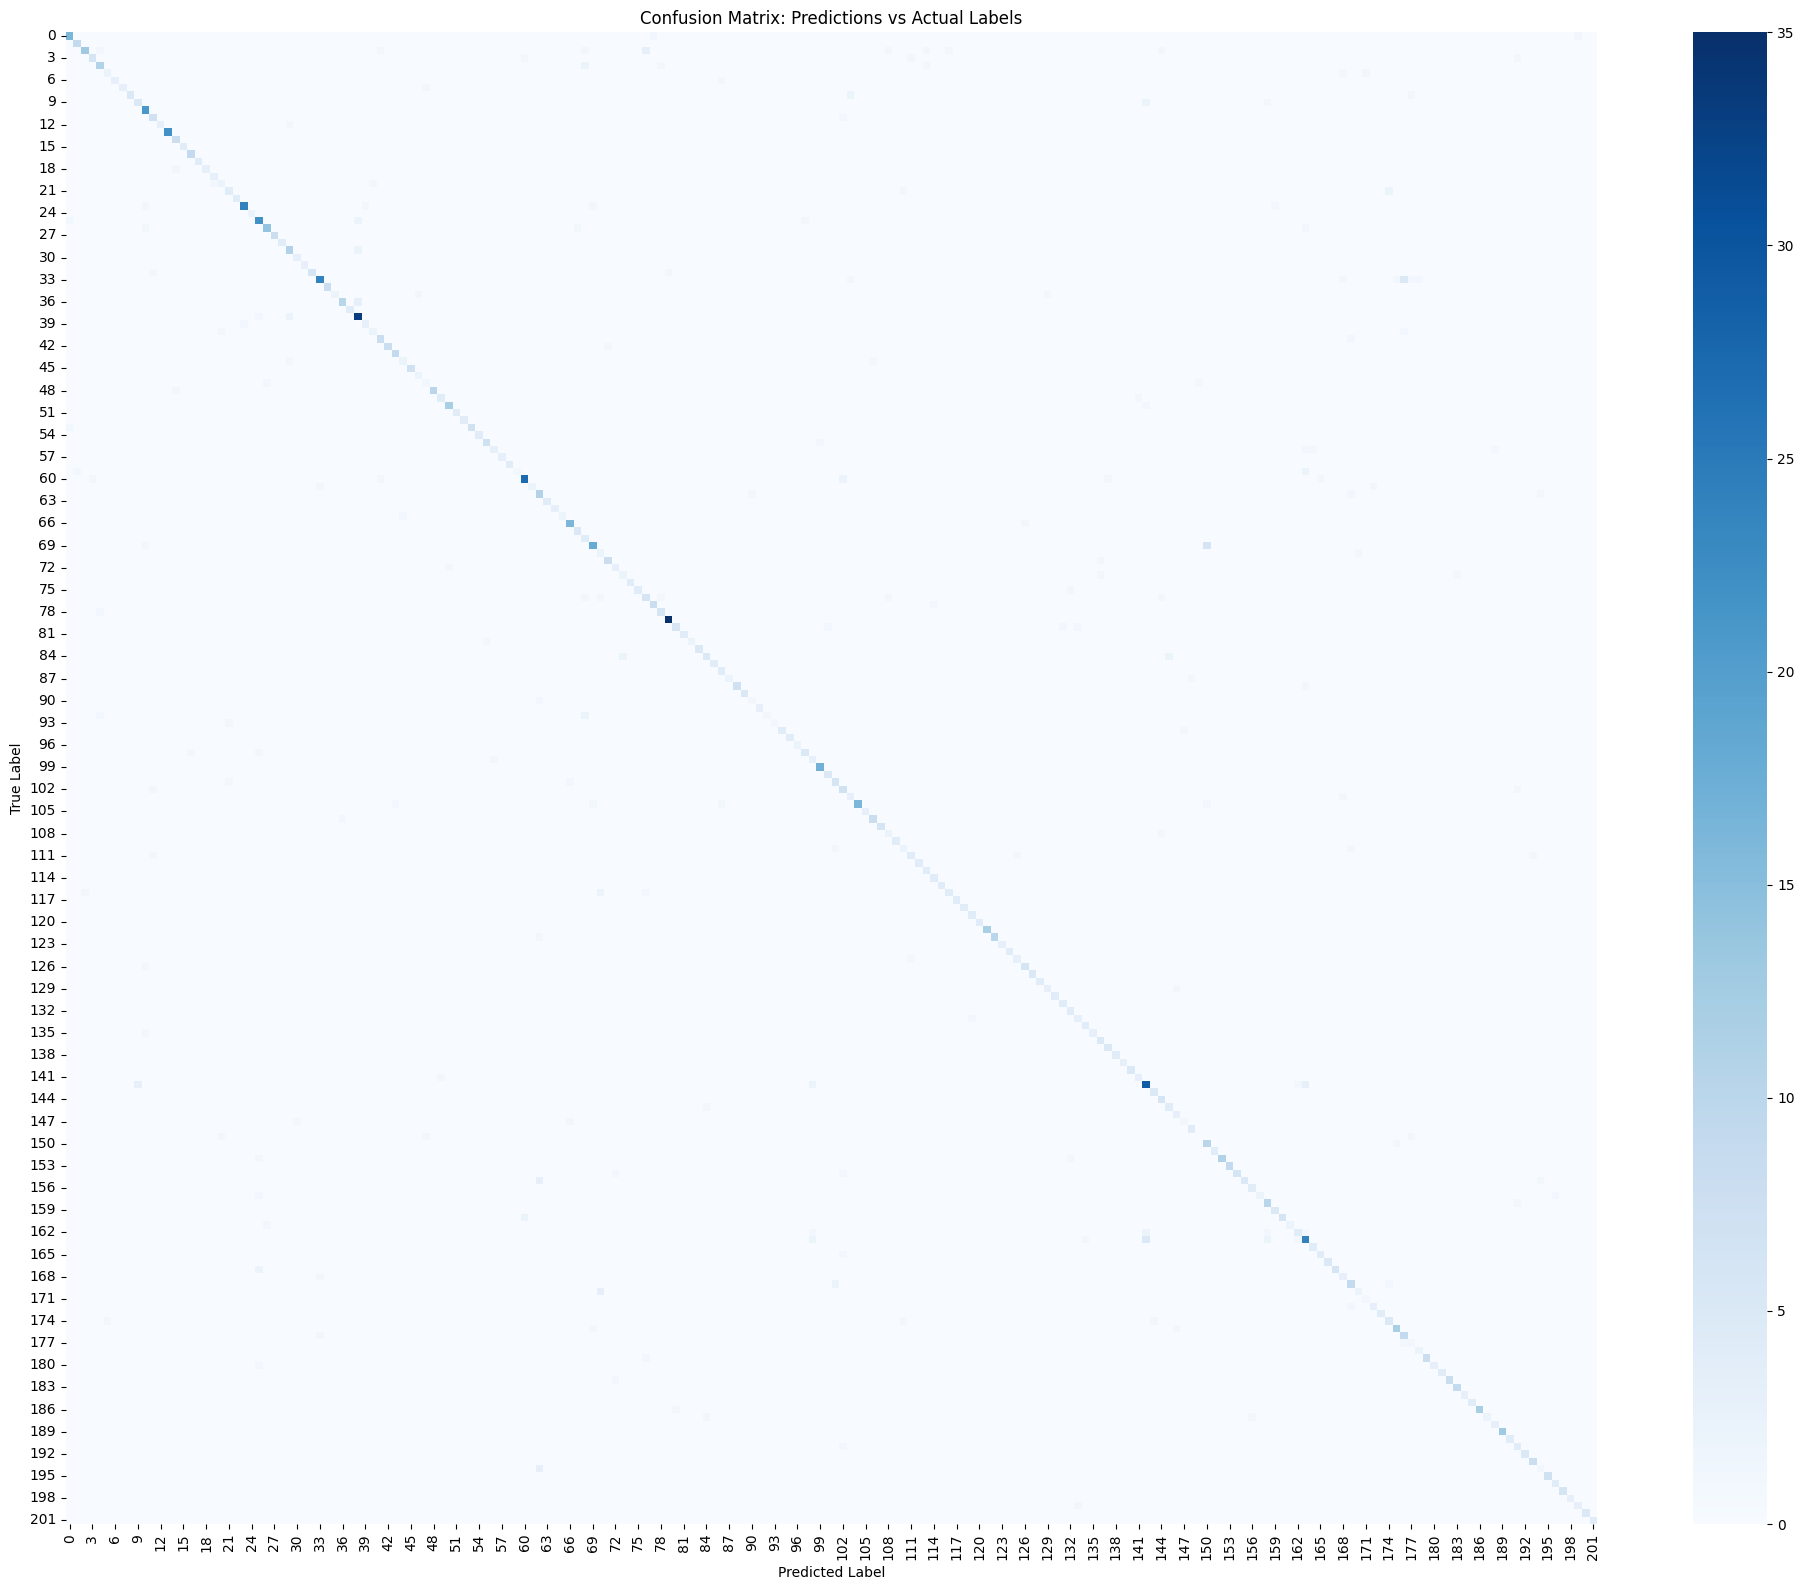

Confusion Matrix Shape: (202, 202)
Total Predictions: 1495


In [169]:
# Create confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(20, 16))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', cbar=True)         # annot=np.where(cm > 0, cm, ""), annot_kws={"size": 5}
plt.title('Confusion Matrix: Predictions vs Actual Labels')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Print shape and summary
print(f"Confusion Matrix Shape: {cm.shape}")
print(f"Total Predictions: {cm.sum()}")

In [170]:
# y_pred_classes[1]
dict(test_generator.class_indices.items())[low_images_class]

24

In [171]:
def class_metrics(class_name):

    class_idx = test_generator.class_indices[class_name]

    TP = int(cm[class_idx, class_idx])
    FN = int(cm[class_idx, :].sum() - TP)   # actual positives missed
    FP = int(cm[:, class_idx].sum() - TP)   # predicted as this class but not actual
    TN = int(cm.sum() - (TP + FP + FN))
    support = TP + FN
    
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0   #per-class accuracy / sensitivity
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    class_accuracy = (TP + TN) / cm.sum()               # accuracy treating this class vs rest
    
    # class_name =idx_to_class[class_idx]
    print(f"Class: {class_name} (index={class_idx})")
    print(f" Support (true samples) : {support}")
    print(f" TP: {TP} | FN: {FN} | FP: {FP} | TN: {TN}")
    print(f" Precision : {precision:.4f}")
    print(f" Recall    : {recall:.4f}")     
    print(f" F1-score  : {f1:.4f}")
    print(f" Class-wise accuracy : {class_accuracy:.4f}")



In [172]:
class_metrics(low_images_class)

Class: brachypteraciidae (index=24)
 Support (true samples) : 2
 TP: 2 | FN: 0 | FP: 0 | TN: 1493
 Precision : 1.0000
 Recall    : 1.0000
 F1-score  : 1.0000
 Class-wise accuracy : 1.0000


## Metadata

In [173]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, f1_score

In [174]:
def predict_with_metadata(model, test_generator, test_df, phylum_to_families):
    all_preds = []

    # Make sure generator is reset
    test_generator.reset()

    # Loop over batches
    for i in range(len(test_generator)):
        x_batch, y_batch = test_generator[i]  # batch of images
        batch_start = i * test_generator.batch_size
        batch_end = batch_start + x_batch.shape[0]
        
        # Get corresponding phyla from dataframe
        phylum_batch = test_df['phylum'].iloc[batch_start:batch_end].values
        
        # Get model logits
        logits = model.predict(x_batch)  # shape: (batch_size, 202)
        
        # Apply logit filtering per image
        batch_preds = []
        for j in range(len(x_batch)):
            phylum = phylum_batch[j]
            valid_families = phylum_to_families[phylum]

            mask = np.full_like(logits[j], -np.inf)
            mask[valid_families] = 0
            filtered_logits = logits[j] + mask

            probs = tf.nn.softmax(filtered_logits).numpy()
            pred_family = int(np.argmax(probs))
            batch_preds.append(pred_family)
        
        all_preds.extend(batch_preds)
    
    return np.array(all_preds)


In [175]:
# Create mapping from family to sparse ID
family_to_id = train_generator.class_indices

# Create mapping from phylum to family
phylum_to_families = {}

for phylum, group in train_df.groupby("phylum"):
    families = group["family"].unique()                
    family_ids = [family_to_id[f] for f in families]   # Convert to sparse IDs
    phylum_to_families[phylum] = family_ids

In [176]:
print(phylum_to_families)

{'arthropoda': [79, 128, 151, 13, 88, 185, 49, 32, 17, 141, 109, 139, 37, 130, 124, 188, 184], 'chordata': [30, 80, 175, 77, 33, 25, 162, 62, 38, 158, 99, 3, 189, 47, 191, 59, 125, 98, 41, 131, 135, 71, 19, 0, 169, 82, 155, 86, 18, 126, 36, 183, 127, 50, 16, 182, 156, 154, 1, 152, 96, 45, 186, 42, 9, 40, 101, 26, 111, 177, 165, 122, 142, 153, 48, 55, 60, 174, 160, 23, 10, 105, 67, 167, 140, 145, 100, 94, 27, 143, 69, 72, 83, 106, 75, 120, 176, 163, 58, 102, 194, 15, 54, 198, 149, 197, 104, 159, 56, 29, 97, 187, 7, 107, 44, 112, 118, 119, 181, 65, 43, 178, 64, 114, 173, 195, 129, 192, 5, 85, 74, 66, 150, 8, 117, 132, 168, 134, 73, 148, 53, 31, 172, 164, 93, 21, 63, 137, 171, 133, 138, 35, 46, 166, 22, 180, 190, 12, 11, 84, 110, 28, 6, 89, 103, 39, 61, 14, 146, 200, 147, 20, 121, 123, 87, 136, 157, 90, 196, 51, 199, 115, 95, 57, 161, 24], 'cnidaria': [70, 108, 2, 78, 144, 4, 68, 116, 76, 170, 81, 113, 92], 'echinodermata': [179], 'mollusca': [193, 201, 52, 91, 34]}


In [ ]:
# Get predictions with metadata
predictions_with_metadata = predict_with_metadata(tuned_model, test_generator, test_df, phylum_to_families)

# Get true labels
y_true = test_generator.classes

In [178]:
# Calculate metrics
acc = accuracy_score(y_true, predictions_with_metadata)
f1_micro = f1_score(y_true, predictions_with_metadata, average='micro')
f1_macro = f1_score(y_true, predictions_with_metadata, average='macro')
f1_weighted = f1_score(y_true, predictions_with_metadata, average='weighted')


# Print the metrics
print("--- Model performance WITH metadata: ---")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score (Micro): {f1_micro:.4f}")
print(f"F1 Score (Macro): {f1_macro:.4f}")
print(f"F1 Score (Weighted): {f1_weighted:.4f}")

--- Model performance WITH metadata: ---
Accuracy: 0.8388
F1 Score (Micro): 0.8388
F1 Score (Macro): 0.8291
F1 Score (Weighted): 0.8383
